In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib
from scipy.integrate import simpson

plt.style.use('../Analysis/sty.mplstyle')

In [2]:
####################################################################################################################
################################# (Anti)Neutrino Flux in (Anti)Neutrino Mode #######################################
####################################################################################################################
Energy_numu_NuMI_nuMode = np.loadtxt('Digitized_Dataset_NuMI_offaxis_numu_nuMode.txt', delimiter=',', usecols=0) # GeV
numu_Flux_offaxis_NuMI_nuMode = np.loadtxt('Digitized_Dataset_NuMI_offaxis_numu_nuMode.txt', delimiter=',', usecols=1) #numu/GeV/POT

Energy_numubar_NuMI_nuMode = np.loadtxt('Digitized_Dataset_NuMI_offaxis_numubar_nuMode.txt', delimiter=',', usecols=0) # GeV
numubar_Flux_offaxis_NuMI_nuMode = np.loadtxt('Digitized_Dataset_NuMI_offaxis_numubar_nuMode.txt', delimiter=',', usecols=1) #numubar/GeV/POT

Energy_numu_NuMI_AntinuMode = np.loadtxt('Digitized_Dataset_NuMI_offaxis_numu_AntinuMode.txt', delimiter=',', usecols=0) # GeV
numu_Flux_offaxis_NuMI_AntinuMode = np.loadtxt('Digitized_Dataset_NuMI_offaxis_numu_AntinuMode.txt', delimiter=',', usecols=1) #numu/GeV/POT

Energy_numubar_NuMI_AntinuMode = np.loadtxt('Digitized_Dataset_NuMI_offaxis_numubar_AntinuMode.txt', delimiter=',', usecols=0) # GeV
numubar_Flux_offaxis_NuMI_AntinuMode = np.loadtxt('Digitized_Dataset_NuMI_offaxis_numubar_AntinuMode.txt', delimiter=',', usecols=1) #numubar/GeV/POT

# Define the quantities to Normalize the Digitized Flux
length_ICARUS = 1 # meter
width_ICARUS = 1 # meter
Area_ICARUS = length_ICARUS * width_ICARUS # m^2

# Give the Flux units of nu/m^2/GeV/POT
Flux_NuMI_offaxis_numu_nuMode_csv = numu_Flux_offaxis_NuMI_nuMode/Area_ICARUS
Flux_NuMI_offaxis_numubar_nuMode_csv = numubar_Flux_offaxis_NuMI_nuMode/Area_ICARUS
Flux_NuMI_offaxis_numu_AntinuMode_csv = numu_Flux_offaxis_NuMI_AntinuMode/Area_ICARUS
Flux_NuMI_offaxis_numubar_AntinuMode_csv = numubar_Flux_offaxis_NuMI_AntinuMode/Area_ICARUS

# Data to create the list [E_min, Ehigh, Prob]
Energy_NuMI_csv = np.linspace(0.05, 5.95, 60)
Elow_NuMI_csv = Energy_NuMI_csv - 0.05
Ehigh_NuMI_csv = Energy_NuMI_csv + 0.05

# Computing the total Flux
numu_total_flux_ICARUS_offaxis_nuMode = simpson(Flux_NuMI_offaxis_numu_nuMode_csv, Energy_numu_NuMI_nuMode)
numubar_total_flux_ICARUS_offaxis_nuMode = simpson(Flux_NuMI_offaxis_numubar_nuMode_csv, Energy_numubar_NuMI_nuMode)
numu_total_flux_ICARUS_offaxis_AntinuMode = simpson(Flux_NuMI_offaxis_numu_AntinuMode_csv, Energy_numu_NuMI_AntinuMode)
numubar_total_flux_ICARUS_offaxis_AntinuMode = simpson(Flux_NuMI_offaxis_numubar_AntinuMode_csv, Energy_numubar_NuMI_AntinuMode)

# Initialize to zero the normalized probabilities
numu_normProb_ICARUS_offaxis_nuMode = np.zeros_like(Flux_NuMI_offaxis_numu_nuMode_csv)
numubar_normProb_ICARUS_offaxis_nuMode = np.zeros_like(Flux_NuMI_offaxis_numubar_nuMode_csv)
numu_normProb_ICARUS_offaxis_AntinuMode = np.zeros_like(Flux_NuMI_offaxis_numu_AntinuMode_csv)
numubar_normProb_ICARUS_offaxis_AntinuMode = np.zeros_like(Flux_NuMI_offaxis_numubar_AntinuMode_csv)

# Compute the Normalized Probabilities
for i in range(len(numu_normProb_ICARUS_offaxis_nuMode)):
    bin_width = Ehigh_NuMI_csv[i] - Elow_NuMI_csv[i]
    numu_normProb_ICARUS_offaxis_nuMode[i] = Flux_NuMI_offaxis_numu_nuMode_csv[i]*bin_width/numu_total_flux_ICARUS_offaxis_nuMode

for i in range(len(numubar_normProb_ICARUS_offaxis_nuMode)):
    bin_width = Ehigh_NuMI_csv[i] - Elow_NuMI_csv[i]
    numubar_normProb_ICARUS_offaxis_nuMode[i] = Flux_NuMI_offaxis_numubar_nuMode_csv[i]*bin_width/numubar_total_flux_ICARUS_offaxis_nuMode

for i in range(len(numu_normProb_ICARUS_offaxis_AntinuMode)):
    bin_width = Ehigh_NuMI_csv[i] - Elow_NuMI_csv[i]
    numu_normProb_ICARUS_offaxis_AntinuMode[i] = Flux_NuMI_offaxis_numu_AntinuMode_csv[i]*bin_width/numu_total_flux_ICARUS_offaxis_AntinuMode

for i in range(len(numubar_normProb_ICARUS_offaxis_AntinuMode)):
    bin_width = Ehigh_NuMI_csv[i] - Elow_NuMI_csv[i]
    numubar_normProb_ICARUS_offaxis_AntinuMode[i] = Flux_NuMI_offaxis_numubar_AntinuMode_csv[i]*bin_width/numubar_total_flux_ICARUS_offaxis_AntinuMode

# Writing to CSV
with open("../csv/Fluxes/NormProb/nu_NormProb_ICARUS_offaxis_nuMode.txt", mode='w', newline="") as file:
    file.write("########################################################################################## \n")
    file.write(f"#####\t Integrated Neutrino Flux (Neutrino Mode): {numu_total_flux_ICARUS_offaxis_nuMode} m^-2 POT^-1 \n")
    file.write("########################################################################################## \n")
    for e_low, e_high, p_norm in (zip(Elow_NuMI_csv, Ehigh_NuMI_csv, numu_normProb_ICARUS_offaxis_nuMode)):
        file.write(f"\t {e_low:.4f}, \t {e_high:.4f}, \t {p_norm:.22f}, \n")
        
with open("../csv/Fluxes/NormProb/antinu_NormProb_ICARUS_offaxis_nuMode.txt", mode='w', newline="") as file:
    file.write("########################################################################################## \n")
    file.write(f"#####\t Integrated AntiNeutrino Flux (Neutrino Mode): {numubar_total_flux_ICARUS_offaxis_nuMode} m^-2 POT^-1 \n")
    file.write("########################################################################################## \n")
    for e_low, e_high, p_norm in (zip(Elow_NuMI_csv, Ehigh_NuMI_csv, numubar_normProb_ICARUS_offaxis_nuMode)):
        file.write(f"\t {e_low:.4f}, \t {e_high:.4f}, \t {p_norm:.22f}, \n")

with open("../csv/Fluxes/NormProb/nu_NormProb_ICARUS_offaxis_antinuMode.txt", mode='w', newline="") as file:
    file.write("########################################################################################## \n")
    file.write(f"#####\t Integrated Neutrino Flux (AntiNeutrino Mode): {numu_total_flux_ICARUS_offaxis_AntinuMode} m^-2 POT^-1 \n")
    file.write("########################################################################################## \n")
    for e_low, e_high, p_norm in (zip(Elow_NuMI_csv, Ehigh_NuMI_csv, numu_normProb_ICARUS_offaxis_AntinuMode)):
        file.write(f"\t {e_low:.4f}, \t {e_high:.4f}, \t {p_norm:.22f}, \n")

with open("../csv/Fluxes/NormProb/antinu_NormProb_ICARUS_offaxis_antinuMode.txt", mode='w', newline="") as file:
    file.write("########################################################################################## \n")
    file.write(f"#####\t Integrated AntiNeutrino Flux (AntiNeutrino Mode): {numubar_total_flux_ICARUS_offaxis_AntinuMode} m^-2 POT^-1 \n")
    file.write("########################################################################################## \n")
    for e_low, e_high, p_norm in (zip(Elow_NuMI_csv, Ehigh_NuMI_csv, numubar_normProb_ICARUS_offaxis_AntinuMode)):
        file.write(f"\t {e_low:.4f}, \t {e_high:.4f}, \t {p_norm:.22f}, \n")

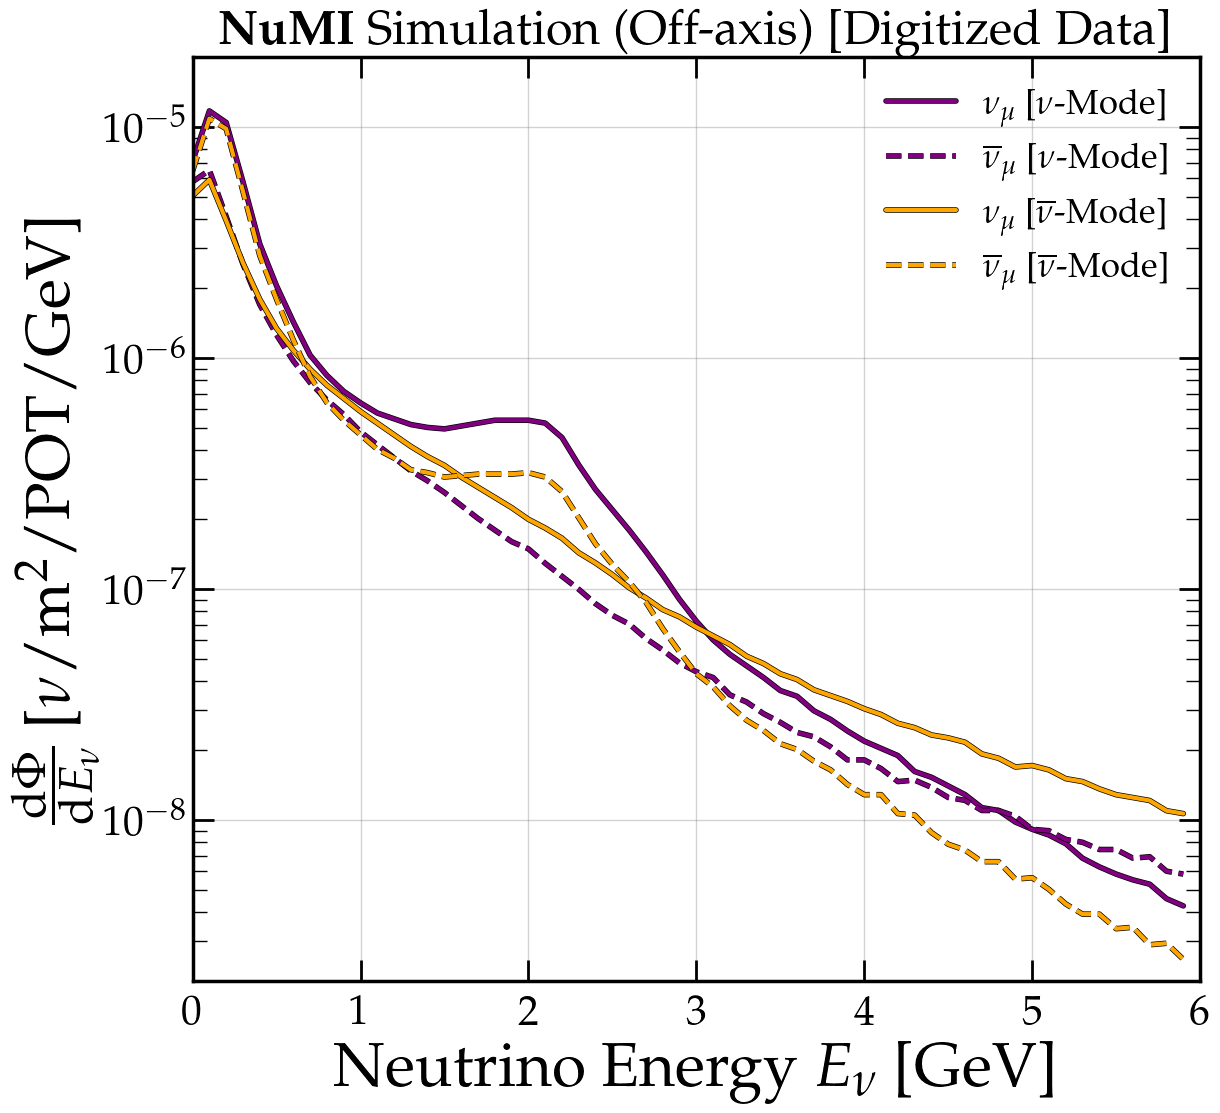

In [3]:
fig = plt.figure()
ax = fig.add_subplot()


ax.plot(Elow_NuMI_csv, Flux_NuMI_offaxis_numu_nuMode_csv, ls='-', color='purple', label=r'$\nu_\mu$ [$\nu$-Mode]', path_effects=[pe.Stroke(linewidth=4, foreground='k'), pe.Normal()])
ax.plot(Elow_NuMI_csv, Flux_NuMI_offaxis_numubar_nuMode_csv, ls='--', color='purple', label=r'$\overline{\nu}_\mu$ [$\nu$-Mode]', path_effects=[pe.Stroke(linewidth=4, foreground='k'), pe.Normal()])
ax.plot(Elow_NuMI_csv, Flux_NuMI_offaxis_numu_AntinuMode_csv, ls='-', color='orange', label=r'$\nu_\mu$ [$\overline{\nu}$-Mode]', path_effects=[pe.Stroke(linewidth=4, foreground='k'), pe.Normal()])
ax.plot(Elow_NuMI_csv, Flux_NuMI_offaxis_numubar_AntinuMode_csv, ls='--', color='orange', label=r'$\overline{\nu}_\mu$ [$\overline{\nu}$-Mode]', path_effects=[pe.Stroke(linewidth=4, foreground='k'), pe.Normal()])

ax.legend(fontsize=25, loc='upper right', frameon=False, framealpha=1, edgecolor='k', fancybox=True)
ax.set_yscale('log')
ax.set_ylim([2e-9, 2e-5])
ax.set_xlim([0,6])

ax.xaxis.grid(True, ls='-', which='major', color='gray', alpha=0.35)
ax.yaxis.grid(True, ls='-', which='major', color='gray', alpha=0.35)

ax.set_title(r'{\bf NuMI} Simulation (Off-axis) [Digitized Data]')
ax.set_ylabel(r'$\frac{\mathrm{d} \Phi}{\mathrm{d} E_\nu}$  [$\nu$/m$^2$/POT/GeV]')
ax.set_xlabel(r'Neutrino Energy $E_\nu$ [GeV]')

plt.savefig('../Plots/Figures_PDF/ICARUS_Flux.pdf', transparent=False, bbox_inches='tight')
plt.savefig('../Plots/Figures_PNG/ICARUS_Flux.png', transparent=False, bbox_inches='tight')